In [2]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import gmean

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

def safe_gmean(x):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    valid_x = x.dropna()
    valid_x = valid_x[valid_x > 0]
    if valid_x.empty:
        return np.nan
    return gmean(valid_x)

def get_algorithm_labels(locations):
    """
    Takes a list of file paths and returns a list of formatted algorithm labels.
    """
    def map_single(location_string):
        filename = os.path.basename(location_string).replace('.json', '')
        clean_name = filename.replace('query-results-raw-', '')

        # Extract size suffix and base algorithm name
        if clean_name[-2:].lower() in ['-s', '-m', '-l']:
            size = clean_name[-1].lower()
            base_type = clean_name[:-2]
        else:
            return clean_name  # Fallback if no valid size suffix exists

        # Apply mapping rules
        mapping = {
            'cache': 'unindexed-cache',
            'query-cache': 'indexed-cache',
            'query-cache-estimate': 'indexed-cache-estimation'
        }

        mapped_type = mapping.get(base_type, base_type)
        return f"{mapped_type}-{size}"

    return [map_single(loc) for loc in locations]


def investigate_refinement_patterns(baseline_locations, cache_locations, custom_labels=None):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Calculate depth from patternIds array
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                time_val = item.get('time')
                timestamps = item.get("timestamps", [])
                num_timestamps = len(timestamps)

                # Strict filtering
                time_first = timestamps[0] if num_timestamps > 0 else pd.NA
                time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
                has_results = num_timestamps > 0

                # Pre-calculate temporal and throughput metrics per individual run
                compute_time = pd.NA
                if has_results and pd.notna(time_first) and pd.notna(time_val):
                    compute_time = max(0, time_val - time_first)

                throughput = 0.0
                if has_results and pd.notna(time_last) and time_last > 0:
                    throughput = num_timestamps / time_last

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'time': time_val,
                    "time_first": time_first,
                    "compute_time": compute_time,
                    "throughput": throughput,
                    "has_results": has_results,
                    "num_timestamps": num_timestamps,
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences: Keep refinements AND the initial base template preceding them
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    # Aggregate Baseline (Median)
    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
        time_baseline=('time', 'median'),
        time_first_baseline=('time_first', 'median'),
        throughput_baseline=('throughput', 'median')
    ).reset_index()

    # Determine labels
    if custom_labels is None:
        target_labels = get_algorithm_labels(cache_locations)
    else:
        target_labels = custom_labels

    # Process Cache Data
    final_cache_dfs = []
    for cache_loc, full_label in zip(cache_locations, target_labels):
        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        # Extract base algorithm and size for faceting
        if full_label[-2:].lower() in ['-s', '-m', '-l']:
            cache_size = full_label[-1].upper()
            algorithm_name = full_label[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = full_label

        # Aggregate Cache (Median for base absolute values)
        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
            time=('time', 'median'),
            time_first=('time_first', 'median'),
            compute_time=('compute_time', 'median'),
            throughput=('throughput', 'median'),
            hit_ratio=('hit_ratio', 'median'),
            eviction_percentage=('eviction_percentage', 'median')
        ).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_depth'], how='inner')

        # Calculate distinct speedups
        df_merged['speedup_total'] = df_merged['time_baseline'] / df_merged['time']
        df_merged['speedup_first'] = df_merged['time_first_baseline'] / df_merged['time_first']

        # Calculate throughput speedup
        df_merged['speedup_throughput'] = np.where(
            (df_merged['throughput_baseline'] > 0) & (df_merged['throughput'] > 0),
            df_merged['throughput'] / df_merged['throughput_baseline'],
            np.nan
        )

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_cache_metrics(df, save_path="."):
    """
    Generates inline Seaborn plots evaluating cache performance.
    Saves each plot as a PDF to the specified save_path.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)
    # Apply LNCS specific styling to Matplotlib and Seaborn
    rc_params = {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14,
        "figure.titlesize": 14
    }

    # Pass the dictionary to Seaborn's theme setter
    sns.set_theme(style="whitegrid", rc=rc_params)

    # sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    # Pre-process plotting data
    plot_df = df.copy()
    plot_df['hit_ratio_pct'] = plot_df['hit_ratio'] * 100 # Align scales
    algorithm_order = sorted(plot_df['algorithm'].unique().tolist())
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))

    # Define robust, colorblind-friendly markers and line styles
    style_markers = ["o", "s", "^", "D", "v"]
    style_lines = ["-", "--", ":", "-.", "-"]

    # ==========================================
    # Plot A: Combined Hit Ratio & Evictions
    # ==========================================
    g1 = sns.FacetGrid(plot_df, col="cache_size", height=4.5, aspect=1.1)

    def draw_combo(data, **kwargs):
        ax = plt.gca()

        # 1. Background Bars (Evictions)
        sns.barplot(
            data=data, x="refinement_depth", y="eviction_percentage",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind", alpha=0.6, ax=ax, errorbar=None, legend=False
        )

        # 2. Foreground Lines (Hit Ratio)
        sns.pointplot(
            data=data, x="refinement_depth", y="hit_ratio_pct",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=style_lines[:len(algorithm_order)],
            ax=ax, errorbar=None, legend=False
        )

    g1.map_dataframe(draw_combo)

    # Combo Plot Formatting
    g1.set_axis_labels(r"Refinement Depth (0 = Base Template)", r"Percentage (\%)", fontsize=16)
    g1.set_titles(col_template="Cache Size: {col_name}", fontsize=16, fontweight='bold')

    for ax in g1.axes.flat:
        ax.set_ylim(-2, 105) # Add minor padding below 0
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', marker='o', label='Hit Ratio (Line)'),
        mpatches.Patch(color='gray', alpha=0.35, label='Evictions (Bar)')
    ]
    custom_labels = ['Hit Ratio (Line)', 'Evictions (Bar)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        ls = style_lines[i % len(style_lines)]

        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle=ls, markersize=7))
        custom_labels.append(alg)

    # Place legend horizontally above the plots, removing the suptitle
    g1.figure.legend(handles=custom_handles, labels=custom_labels,
                     loc='lower center', bbox_to_anchor=(0.5, 1.05),
                     ncol=3, frameon=True, edgecolor='black')

    g1.figure.tight_layout()

    combo_path = os.path.join(save_path, "combined_cache_efficiency.pdf")
    g1.savefig(combo_path, bbox_inches='tight')
    print(f"Saved: {combo_path}")
    plt.show()


def plot_temporal_throughput_line(df, save_path="."):
    """
    Generates a stylized point plot showing total time and throughput speedups
    across refinement depths, separated by cache size.
    """
    if df.empty:
        print("DataFrame is empty.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Data cleaning
    df_clean = df.copy()
    for col in ['speedup_total', 'speedup_throughput']:
        df_clean[col] = pd.to_numeric(df_clean[col]).fillna(0)

    # Melt data for Seaborn (long format)
    melted_df = df_clean.melt(
        id_vars=['cache_size', 'algorithm', 'refinement_depth'],
        value_vars=['speedup_total', 'speedup_throughput'],
        var_name='Metric',
        value_name='Speedup'
    )

    melted_df['Metric'] = melted_df['Metric'].replace({
        'speedup_total': 'Total Time',
        'speedup_throughput': 'Throughput'
    })

    rc_params = {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14,
        "figure.titlesize": 14
    }

    # Pass the dictionary to Seaborn's theme setter
    sns.set_theme(style="whitegrid", rc=rc_params)

    algorithm_order = sorted(df_clean['algorithm'].unique().tolist())
    cache_order = sorted(df_clean['cache_size'].unique())[::-1]
    colors = sns.color_palette("colorblind", n_colors=len(algorithm_order))

    style_markers = ["o", "s", "^", "D", "v"]

    g = sns.FacetGrid(melted_df, col="cache_size", col_order=cache_order, height=4.5, aspect=1.1)

    def draw_speedup_lines(data, **kwargs):
        ax = plt.gca()

        # Total Time (Solid lines)
        sns.pointplot(
            data=data[data['Metric'] == 'Total Time'],
            x="refinement_depth", y="Speedup",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=["-"] * len(algorithm_order),
            estimator=safe_gmean,
            ax=ax, errorbar=None, legend=False
        )

        # Throughput (Dashed lines)
        sns.pointplot(
            data=data[data['Metric'] == 'Throughput'],
            x="refinement_depth", y="Speedup",
            hue="algorithm", hue_order=algorithm_order,
            palette="colorblind",
            markers=style_markers[:len(algorithm_order)],
            linestyles=["--"] * len(algorithm_order),
            estimator=safe_gmean,
            ax=ax, errorbar=None, legend=False
        )

    g.map_dataframe(draw_speedup_lines)

    g.set_axis_labels("Refinement Depth (0 = Base Template)", "Geometric Mean Speedup (vs No Cache)", fontsize=16)
    g.set_titles(col_template="Cache Size: {col_name}", fontsize=16, fontweight='bold')

    for ax in g.axes.flat:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

        ylim = ax.get_ylim()
        new_top = max(ylim[1], 2.5)
        ax.set_ylim(bottom=0, top=new_top)

        ylim = ax.get_ylim()
        ticks = ax.get_yticks()

        if len(ticks) > 1:
            step = ticks[1] - ticks[0]
            if step > 0:
                min_tick = 1.0 - np.ceil((1.0 - ylim[0]) / step) * step
                max_tick = 1.0 + np.ceil((ylim[1] - 1.0) / step) * step
                new_ticks = np.arange(min_tick, max_tick + step / 2, step)
                new_ticks = new_ticks[new_ticks >= 0]
                ax.set_yticks(new_ticks)

        ax.set_ylim(bottom=0, top=ylim[1])
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

    # Build Custom Legend
    custom_handles = [
        mlines.Line2D([], [], color='black', linestyle='-', label='Total Time (Solid)'),
        mlines.Line2D([], [], color='black', linestyle='--', label='Throughput (Dashed)')
    ]
    custom_labels = ['Total Time (Solid)', 'Throughput (Dashed)']

    for i, alg in enumerate(algorithm_order):
        c = colors[i]
        m = style_markers[i % len(style_markers)]
        custom_handles.append(mlines.Line2D([], [], color=c, marker=m, linestyle='', markersize=8))
        custom_labels.append(alg)

    # Place legend horizontally above the plots, removing the suptitle
    g.figure.legend(handles=custom_handles, labels=custom_labels,
                    loc='lower center', bbox_to_anchor=(0.5, 1.05),
                    ncol=3, frameon=True, edgecolor='black')

    g.figure.tight_layout()

    save_target = os.path.join(save_path, "temporal_throughput_line.pdf")
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution block
if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_caches = [
        raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
        raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
        raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l
    ]

    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    df_final = investigate_refinement_patterns(location_default, all_caches)
    plot_refinement_cache_metrics(df_final, "../output/refinement_figures")
    plot_temporal_throughput_line(df_final, "../output/refinement_figures")

FileNotFoundError: [Errno 2] No such file or directory: '../data/query-results-raw-default.json'

In [ ]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

# Dummy map for pattern IDs to structural types
# Update this dictionary with your actual pattern ID mappings
PATTERN_TYPE_MAP = {
    0: "Add Filter",
    1: "Add Join",
    2: "Add Optional",
    3: "Add Union",
    4: "Change Limit/Offset",
    5: "Change Order"
}

def investigate_refinement_types(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Extract the latest pattern ID to determine the current refinement type
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                if refinement_depth > 0:
                    latest_pattern_id = pattern_ids[-1]
                    ref_type = PATTERN_TYPE_MAP.get(latest_pattern_id, f"Type {latest_pattern_id}")
                else:
                    ref_type = "Base Template"

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'refinement_type': ref_type,
                    'time': item.get('time')
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences to maintain valid comparison chains
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_type'])['time'].median().reset_index()
    df_base_agg.rename(columns={'time': 'time_baseline'}, inplace=True)

    # 2. Process Cache Data
    final_cache_dfs = []
    for cache_loc in cache_locations:
        raw_filename = os.path.basename(cache_loc).replace('.json', '')

        clean_name = raw_filename.replace('query-results-raw-', '')
        if clean_name[-2:] in ['-s', '-m', '-l', '-S', '-M', '-L']:
            cache_size = clean_name[-1].upper()
            algorithm_name = clean_name[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = clean_name

        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_type']).agg({
            'time': 'median',
            'hit_ratio': 'median',
            'eviction_percentage': 'median'
        }).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_type'], how='inner')
        df_merged['speedup'] = df_merged['time_baseline'] / df_merged['time']

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_types(df):
    """
    Generates inline Seaborn bar plots evaluating cache performance
    across refinement types, faceted by Cache Size.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(df['algorithm'].unique().tolist())

    # Exclude Base Template from plots to focus on the impact of the specific refinement patterns
    df_plot = df[df['refinement_type'] != "Base Template"]

    # Plot A: Hit Ratio by Type
    g1 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="hit_ratio",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="viridis",
        errorbar=None
    )
    g1.set_axis_labels("Refinement Type", "Median Hit Ratio")
    g1.set_titles("Cache Size: {col_name}")
    g1.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g1.fig.suptitle("Impact of Refinement Pattern Type on Cache Hit Ratio")
    plt.show()

    # Plot B: Evictions by Type
    g2 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="eviction_percentage",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="flare",
        errorbar=None
    )
    g2.set_axis_labels("Refinement Type", "Median Eviction Percentage (%)")
    g2.set_titles("Cache Size: {col_name}")
    g2.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g2.fig.suptitle("Cache Thrashing Driven by Refinement Pattern Type")
    plt.show()

    # Plot C: Speedup by Type
    g3 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="speedup",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="mako",
        errorbar=None
    )
    g3.set_axis_labels("Refinement Type", "Median Speedup (vs Uncached)")
    g3.set_titles("Cache Size: {col_name}")
    g3.set_xticklabels(rotation=45, ha="right")
    g3.refline(y=1.0, color="red", linestyle="--", label="Baseline (1x)")
    plt.subplots_adjust(top=0.85)
    g3.fig.suptitle("Execution Speedup per Refinement Pattern Type")
    plt.show()

# Execution block
if __name__ == "__main__":
    # Assuming file location lists (all_caches, location_default) are defined as before
    # df_final_types = investigate_refinement_types(location_default, all_caches)
    # plot_refinement_types(df_final_types)
    pass

In [24]:
from load_raw_data import yield_sequence_topologies
# Python artifact mapping refinement patterns to their underlying chokepoints for regression analysis
import json
import pandas as pd

# Python artifact mapping refinement patterns to their underlying chokepoints for regression analysis

refinements_mapping = {
    "interactive-discover-1": {
        0: ['P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.4.r', 'T.1.r', 'T.3.r'],
        2: ['P.3.a'],
        3: ['P.3.r'],
        4: ['P.3.r'],
        5: ['P.1.a'],
        6: ['P.1.r'],
        7: ['T.2.a'],
        8: ['T.2.r'],
    },
    "interactive-discover-2": {
        0: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        2: ['P.3.r', 'T.1.r', 'T.4.r'],
        3: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        4: ['P.4.a'],
        5: ['P.4.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['P.1.a', 'P.2.a'],
        9: ['P.1.r', 'P.2.r'],
        10: ['T.2.a'],
        11: ['T.2.r'],
    },
    "interactive-discover-3": {
        0: ['P.1.a', 'T.2.a'],
        1: ['P.4.a'],
        2: ['T.2.r'],
        3: ['P.4.r'],
        4: ['T.4.a'],
        5: ['T.4.r'],
        7: ['T.1.a', 'P.3.a'],
        8: ['P.4.a'],
        9: ['T.1.r', 'P.3.r'],
        10: ['P.4.r'],
        11: ['P.1.a', 'P.2.a'],
        12: ['P.1.a', 'P.2.a'],
        13: ['P.1.r'],
        14: ['P.1.r'],
        15: ['T.2.a'],
        16: ['T.2.r'],
    },
    "interactive-discover-4": {
        0: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        3: ['P.2.a', 'P.4.a', 'T.4.a'],
        4: ['P.2.r', 'P.4.r', 'T.4.r'],
        6: ['P.3.a', 'T.1.a', 'T.3.a'],
        7: ['P.3.r', 'T.1.r', 'T.3.r'],
        8: ['P.1.a'],
        9: ['P.1.r'],
        10: ['T.2.r'],
        11: ['T.2.a'],
    },
    "interactive-discover-5": {
        1: ['P.3.a', 'T.4.a'],
        2: ['P.3.r', 'T.4.r'],
        3: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        4: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        5: ['T.1.a', 'P.3.a'],
        6: ['T.1.r', 'P.3.r'],
        7: ['P.1.a'],
        8: ['P.1.r'],
        9: ['T.2.a'],
        10: ['T.2.r'],
    },
    "interactive-discover-6": {
        0: ['T.1.a', 'P.4.a'],
        1: ['T.1.r', 'P.4.r'],
        2: ['P.2.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'T.1.r', 'T.3.r'],
        4: ['P.1.a'],
        5: ['P.1.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-discover-7": {
        0: ['P.3.a'],
        1: ['P.3.r'],
        2: ['P.2.a', 'P.4.a'],
        3: ['P.2.r', 'P.4.r'],
        4: ['P.1.a'],
        5: ['P.1.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['T.2.a'],
        9: ['T.2.r'],
    },
    "interactive-discover-8": {
        0: ['T.1.a', 'P.4.a', 'T.3.a'],
        1: ['T.1.r', 'P.4.r', 'T.3.r'],
        2: ['T.3.a', 'P.3.a'],
        3: ['T.3.r', 'P.3.r'],
        4: ['P.2.a', 'P.3.a', 'T.1.a', 'T.3.a'],
        5: ['P.2.r', 'P.3.r', 'T.1.r', 'T.3.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['T.2.a'],
        9: ['T.2.r'],
    },
    "interactive-short-1": {
        0: ['T.1.a', 'T.3.a', 'P.4.a'],
        1: ['T.1.r', 'T.3.r', 'P.4.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a', 'T.4.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r', 'T.4.r'],
        4: ['T.2.a'],
        5: ['T.2.r'],
    },
    "interactive-short-2": {
        0: ['T.1.a', 'T.3.a', 'P.4.a'],
        1: ['T.1.r', 'T.3.r', 'P.4.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        4: ['P.1.a'],
        5: ['P.1.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-3": {
        0: ['P.4.a'],
        1: ['P.4.r'],
        2: ['P.4.a'],
        3: ['P.4.r'],
        4: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        5: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-4": {
        0: ['P.3.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        1: ['P.3.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        2: ['P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.4.r', 'T.1.r', 'T.3.r'],
        4: ['P.4.a', 'P.2.a', 'T.1.a', 'T.3.a'],
        5: ['P.4.r', 'P.2.r', 'T.1.r', 'T.3.r'],
        6: ['P.1.a'],
        7: ['P.1.r'],
        8: ['T.2.a'],
        9: ['T.2.r'],
    },
    "interactive-short-5": {
        0: ['P.3.a', 'T.4.a'],
        1: ['P.3.r', 'T.4.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r', 'T.4.r'],
        4: ['P.4.a'],
        5: ['P.4.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-6": {
        0: ['T.1.a', 'P.4.a'],
        1: ['T.1.r', 'P.4.r'],
        2: ['T.1.a', 'T.3.a', 'P.3.a'],
        3: ['T.1.r', 'T.3.r', 'P.3.r'],
        4: ['P.2.a', 'P.4.a'],
        5: ['P.2.r', 'P.4.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
    "interactive-short-7": {
        0: ['P.3.a', 'T.1.a'],
        1: ['P.3.r'],
        2: ['P.2.a', 'P.4.a', 'T.1.a', 'T.3.a'],
        3: ['P.2.r', 'P.4.r', 'T.1.r', 'T.3.r'],
        6: ['T.2.a'],
        7: ['T.2.r'],
    },
}

def get_cache_hit_rate(record, record_topology):
    """
    Calculates the cache hit rate from the sourceStateQuerySource string.
    Returns a float between 0.0 and 1.0. Returns 0.0 if no accesses occurred.
    """
    cache_data_str = record.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

    if not cache_data_str:
        return 0.0

    try:
        cache_stats = json.loads(cache_data_str)
        hits = cache_stats.get("hits", 0)
        misses = cache_stats.get("misses", 0)
        total_accesses = hits + misses

        if total_accesses == 0:
            return 0.0

        return hits / total_accesses
    except json.JSONDecodeError:
        print(f"Warning: Could not parse cache data for sequence {record.get('name')}, step {record.get('id')}")
        return 0.0

def get_execution_time(record, record_topology):
    """
    Extracts the execution time in milliseconds.
    """
    return float(record.get("time", 0.0))

def get_unique_sources(record, record_topology):
    """
    Extracts the count of unique sources from the topology.
    """
    if not record_topology:
        return 0
    node_dict = record_topology.get("indexToNodeDict", {})
    return len(node_dict)

def get_dependent_variable(record, record_topology):
    """
    STUB: Extract the target metric for your regression.
    e.g., parse the cache hits from "@comunica/persistent-cache-manager:sourceStateQuerySource"
    or calculate Jaccard overlap / unique sources.
    """
    return 0.0

def get_new_data_sources(record):
    pass

def read_topologies(sparql_dir, topology_dir, max_sequences = None):
    mapping = yield_sequence_topologies(sparql_dir, topology_dir, max_sequences)
    return mapping


import json
import pandas as pd

def is_topology_exhausted(record, current_topology_state) -> bool:
    """
    Determine if the generator needs to advance.
    """
    if current_topology_state is None:
        return True

    if record.get("name") != current_topology_state[0]:
        return True

    return False

def obtain_topology(record, generator, current_topology_state, rep_index):
    """
    Evaluates the topology state, steps through the generator if needed,
    and extracts the topology for the specific repetition.
    """
    if is_topology_exhausted(record, current_topology_state):
        try:
            current_topology_state = next(generator)
        except StopIteration:
            raise StopIteration(f"Warning: Topology generator exhausted before record {record.get('name')} step {record.get('id')}.")

    sequence_element_id = int(record.get('id'))

    # Retrieve the list of topologies for all repetitions of this query
    topologies_list = current_topology_state[1].get("sequence")[sequence_element_id].get('topologies')

    # Extract the specific repetition topology using the tracked index
    if topologies_list and rep_index < len(topologies_list):
        rep_specific_topology = topologies_list[rep_index]
    else:
        raise IndexError(f"Warning: Missing topology for {record.get('name')} step {sequence_element_id} rep {rep_index}")
        rep_specific_topology = None

    return current_topology_state, rep_specific_topology

def build_regression_observations(file_path, mapping, topology_generator):
    with open(file_path, 'r') as f:
        data = json.load(f)

    # Ensure sequential processing: group by sequence name, then sort by step ID
    data.sort(key=lambda x: (x.get('name', ''), int(x.get('id', 0))))

    observations = []
    current_sequence = None
    current_topology_state = None

    rep_tracker = {}
    # Track baselines independently for each repetition index using a dictionary of metrics
    previous_metrics = {}

    for record in data:
        seq_name = record.get("name")
        step_id = int(record.get("id"))

        track_key = (seq_name, step_id)
        rep_index = rep_tracker.get(track_key, 0)
        rep_tracker[track_key] = rep_index + 1

        current_topology_state, record_topology = obtain_topology(
            record, topology_generator, current_topology_state, rep_index
        )

        # Extract current state for all three variables
        curr_hit_rate = get_cache_hit_rate(record, record_topology)
        curr_time = get_execution_time(record, record_topology)
        curr_sources = get_unique_sources(record, record_topology)

        # Handle sequence transitions
        if seq_name != current_sequence:
            current_sequence = seq_name
            previous_metrics.clear()

        # Establish baseline for new repetitions
        if rep_index not in previous_metrics:
            previous_metrics[rep_index] = {
                'hit_rate': curr_hit_rate,
                'time': curr_time,
                'sources': curr_sources
            }
            continue

        # Calculate First Differences
        delta_hit_rate = curr_hit_rate - previous_metrics[rep_index]['hit_rate']
        delta_time = curr_time - previous_metrics[rep_index]['time']
        delta_sources = curr_sources - previous_metrics[rep_index]['sources']

        applied_codes = []
        seq_element = record.get("sequenceElement", {})
        template = seq_element.get("template")
        ref_metadata = seq_element.get("refinementMetadata")

        if ref_metadata and "patternIds" in ref_metadata:
            for pid in ref_metadata["patternIds"]:
                if template in mapping and pid in mapping[template]:
                    applied_codes.extend(mapping[template][pid])
                else:
                    print(f"Warning: No mapping found for {template} -> Pattern {pid}")

        observations.append({
            "Sequence_ID": seq_name,
            "Step_ID": step_id,
            "Repetition_Index": rep_index,
            "Applied_Refinement_Patterns": applied_codes,
            "Delta_Hit_Rate": delta_hit_rate,
            "Delta_Time": delta_time,
            "Delta_Sources": delta_sources,
        })

        # Update baselines for the next step
        previous_metrics[rep_index] = {
            'hit_rate': curr_hit_rate,
            'time': curr_time,
            'sources': curr_sources
        }

    # Convert master list to a DataFrame
    df_master = pd.DataFrame(observations)

    # Base columns applicable to all datasets
    base_cols = ["Sequence_ID", "Step_ID", "Repetition_Index", "Applied_Refinement_Patterns"]

    # Split into three separate DataFrames and standardize the target column name
    df_hit_rate = df_master[base_cols + ["Delta_Hit_Rate"]].rename(columns={"Delta_Hit_Rate": "Delta_Y"})
    df_time = df_master[base_cols + ["Delta_Time"]].rename(columns={"Delta_Time": "Delta_Y"})
    df_time["Delta_Y"] = np.sign(df_time["Delta_Y"]) * np.log1p(np.abs(df_time["Delta_Y"]))
    df_sources = df_master[base_cols + ["Delta_Sources"]].rename(columns={"Delta_Sources": "Delta_Y"})
    df_sources["Delta_Y"] = np.sign(df_sources["Delta_Y"]) * np.log1p(np.abs(df_sources["Delta_Y"]))

    return df_hit_rate, df_time, df_sources

topologies = read_topologies(
    "../data/refinement/out-queries",
    "../data/refinement/output-topology-tracking-refinement-l/large",
)

df_hr, df_t, df_src = build_regression_observations('../data/refinement/query-results-raw-refinement-m.json', refinements_mapping, topologies)

# df_observations = build_regression_observations('../data/refinement/query-results-raw-refinement-l.json', refinements_mapping)

#
# print(df_observations.head())

Fitting model with formula: Delta_Y ~ P_1_a + P_1_r + P_2_a + P_2_r + P_3_a + P_3_r + P_4_a + P_4_r + T_1_a + T_1_r + T_2_a + T_2_r + T_3_a + T_3_r + T_4_a + T_4_r - 1

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Delta_Y  
No. Observations: 1330    Method:             REML     
No. Groups:       80      Scale:              0.1754   
Min. group size:  10      Log-Likelihood:     -898.0489
Max. group size:  25      Converged:          Yes      
Mean group size:  16.6                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
P_1_a       -0.053    0.053  -1.016 0.310 -0.157  0.050
P_1_r       -0.145    0.083  -1.748 0.080 -0.307  0.018
P_2_a        0.007    0.064   0.102 0.919 -0.119  0.133
P_2_r        0.307    0.078   3.946 0.000  0.154  0.459
P_3_a       -0.233    0.052  -4.484 0.000 -0.335 -0.131


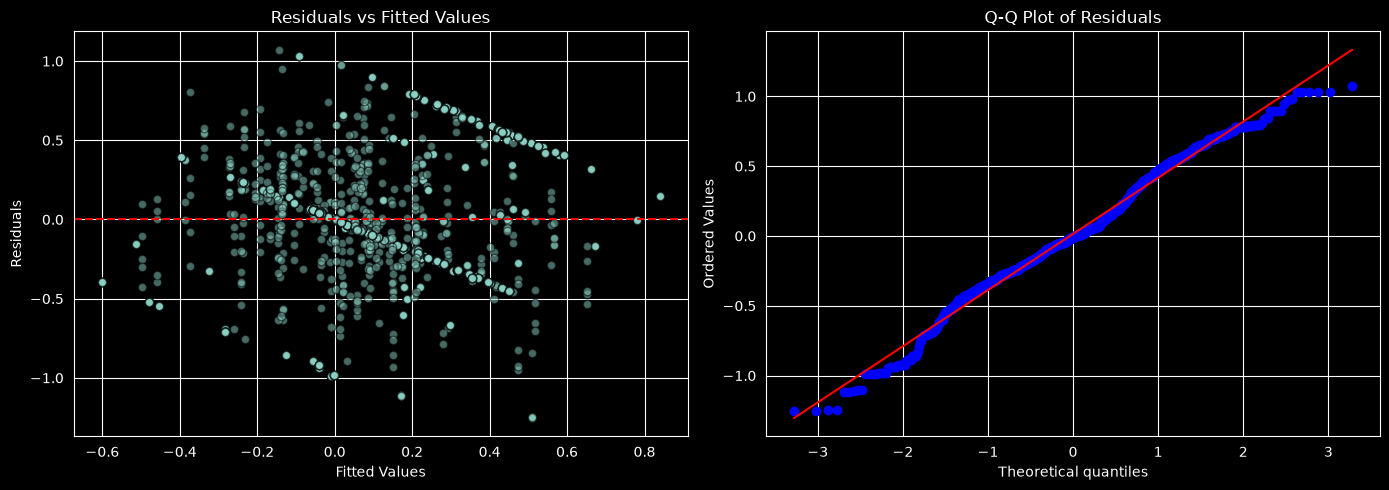

Fitting model with formula: Delta_Y ~ P_1_a + P_1_r + P_2_a + P_2_r + P_3_a + P_3_r + P_4_a + P_4_r + T_1_a + T_1_r + T_2_a + T_2_r + T_3_a + T_3_r + T_4_a + T_4_r - 1



/home/ruben-eschauzier/projects/process-caching-journal/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ruben-eschauzier/projects/process-caching-journal/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/ruben-eschauzier/projects/process-caching-journal/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ruben-eschauzier/projects/process-caching-journal/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/ruben-escha

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Delta_Y   
No. Observations: 1330    Method:             REML      
No. Groups:       80      Scale:              23.9733   
Min. group size:  10      Log-Likelihood:     -4041.8952
Max. group size:  25      Converged:          No        
Mean group size:  16.6                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
P_1_a         -0.681    0.523 -1.303 0.193 -1.706  0.343
P_1_r          2.104    0.947  2.221 0.026  0.248  3.961
P_2_a          0.514    0.598  0.860 0.390 -0.658  1.686
P_2_r         -1.422    0.834 -1.706 0.088 -3.056  0.212
P_3_a          0.208    0.489  0.424 0.672 -0.752  1.167
P_3_r         -1.174    0.703 -1.670 0.095 -2.552  0.204
P_4_a          1.720    0.470  3.660 0.000  0.799  2.641
P_4_r         -3.475    0.704 -4.933 0.00

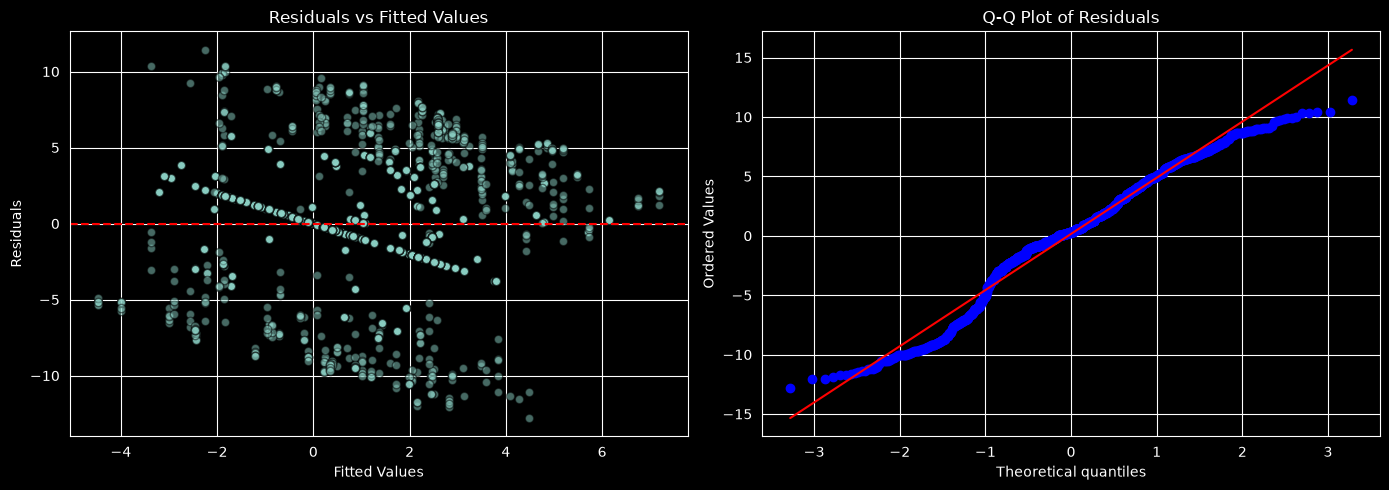

Fitting model with formula: Delta_Y ~ P_1_a + P_1_r + P_2_a + P_2_r + P_3_a + P_3_r + P_4_a + P_4_r + T_1_a + T_1_r + T_2_a + T_2_r + T_3_a + T_3_r + T_4_a + T_4_r - 1

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Delta_Y   
No. Observations: 1330    Method:             REML      
No. Groups:       80      Scale:              43.0123   
Min. group size:  10      Log-Likelihood:     -4428.9774
Max. group size:  25      Converged:          Yes       
Mean group size:  16.6                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
P_1_a         -0.021    0.702 -0.030 0.976 -1.398  1.356
P_1_r         -1.499    1.266 -1.184 0.236 -3.981  0.982
P_2_a         -0.401    0.809 -0.495 0.620 -1.986  1.185
P_2_r          4.658    1.139  4.091 0.000  2.426  6.890
P_3_a          0.530    0.659  0.803 0.422 

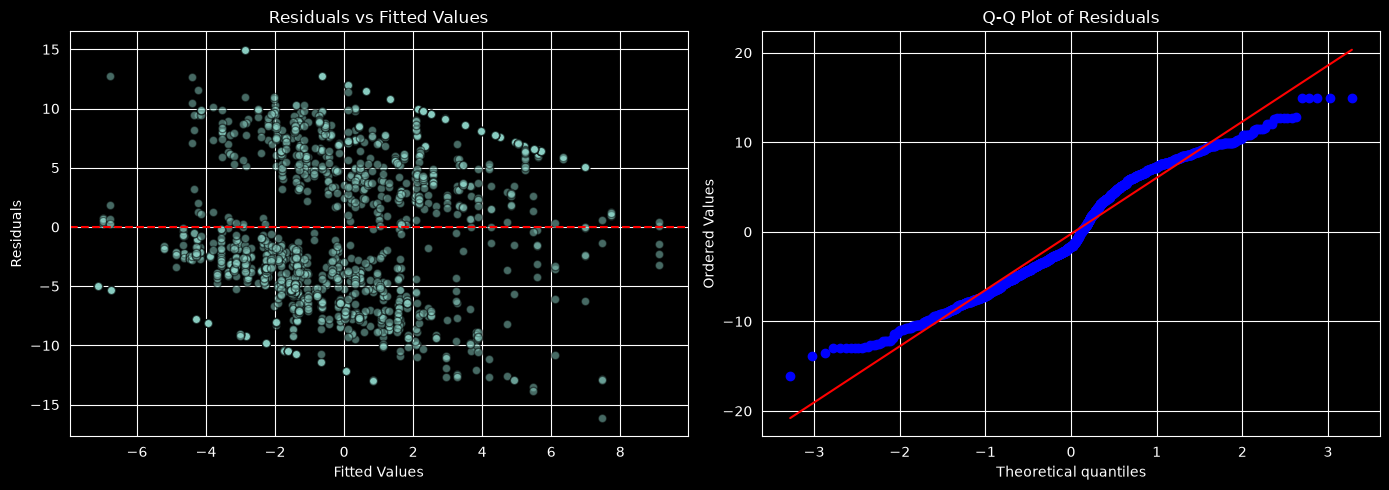

In [25]:
from scipy import stats
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import MultiLabelBinarizer
from matplotlib import pyplot as plt
import numpy as np

def run_mixed_effects_model(df, target_col="Delta_Y", alpha=0.0):
    """
    One-hot encodes the refinement patterns and fits a Linear Mixed-Effects Model
    with a forced zero intercept. Applies L1 regularization if alpha > 0.
    """
    mlb = MultiLabelBinarizer()
    encoded_matrix = mlb.fit_transform(df["Applied_Refinement_Patterns"])

    # Extract class names and sanitize them for statsmodels (replace '.' with '_')
    sanitized_cols = [str(cls).replace('.', '_') for cls in mlb.classes_]

    # Create a DataFrame from the binary matrix
    df_encoded = pd.DataFrame(encoded_matrix, columns=sanitized_cols, index=df.index)

    # Combine the target variable, random effect group, and encoded features
    df_model = pd.concat([df[["Sequence_ID", target_col]], df_encoded], axis=1)

    # Construct the Formula
    features_string = " + ".join(sanitized_cols)
    formula = f"{target_col} ~ {features_string} - 1"

    print(f"Fitting model with formula: {formula}\n")
    try:
        model = smf.mixedlm(formula, df_model, groups=df_model["Sequence_ID"])

        # Apply L1 penalty if alpha is specified. Currently alpha will fail to produce a
        # valid model
        if alpha > 0:
            print(f"Applying L1 regularization (alpha={alpha})...")
            # method='l1' forces the Lasso penalty.
            result = model.fit_regularized(method='l1', alpha=alpha)
        else:
            result = model.fit()

        print(result.summary())
        return result, df_model

    except Exception as e:
        print(f"Model fitting failed: {e}")
        return None, df_model

def evaluate_mixed_model(result, df_model, target_col="Delta_Y"):
    """
    Calculates goodness of fit and diagnostic metrics for a statsmodels MixedLM result.
    """
    if result is None:
        print("Invalid model result.")
        return

    print("=== Mixed-Effects Model Diagnostics ===")

    # 1. Variance Components
    # Variance of the Fixed Effects (predicted values using ONLY fixed parameters)
    # result.predict() by default uses only the fixed effects in statsmodels
    fixed_predictions = result.predict(df_model)
    var_fixed = np.var(fixed_predictions, ddof=1)

    # Variance of the Random Effects (Sequence baseline)
    # result.cov_re gives the covariance matrix of random effects; [0,0] is the intercept variance
    var_random = result.cov_re.iloc[0, 0]

    # Variance of the Residuals (system noise)
    var_residual = result.scale

    total_variance = var_fixed + var_random + var_residual

    # 2. Nakagawa's Pseudo-R^2
    marginal_r2 = var_fixed / total_variance
    conditional_r2 = (var_fixed + var_random) / total_variance

    print(f"Marginal R^2 (Refinements only):   {marginal_r2:.4f}")
    print(f"Conditional R^2 (Full model):      {conditional_r2:.4f}")

    # 3. Intraclass Correlation Coefficient (ICC)
    # Measures the proportion of variance driven by the sequence grouping
    icc = var_random / (var_random + var_residual)
    print(f"Intraclass Correlation (ICC):      {icc:.4f}")

    return {
        "Marginal_R2": marginal_r2,
        "Conditional_R2": conditional_r2,
        "ICC": icc,
        "AIC": result.aic,
        "BIC": result.bic
    }

def plot_residuals(result):
    """
    Plots residual diagnostics to check model assumptions.
    """
    residuals = result.resid
    fitted = result.fittedvalues

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Homoscedasticity Check (Residuals vs Fitted)
    axes[0].scatter(fitted, residuals, alpha=0.5, edgecolors='k')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title('Residuals vs Fitted Values')
    axes[0].set_xlabel('Fitted Values')
    axes[0].set_ylabel('Residuals')

    # Normality Check (Q-Q Plot)
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot of Residuals')

    plt.tight_layout()
    plt.show()

# Example Execution:
# Ensure you have sklearn and statsmodels installed: pip install scikit-learn statsmodels

result_hit_rate, df_model_hr = run_mixed_effects_model(df_hr, alpha=0)
metrics = evaluate_mixed_model(result_hit_rate, df_model_hr, target_col="Delta_Y")
plot_residuals(result_hit_rate)
result_sources, df_model_src = run_mixed_effects_model(df_src, alpha=0)
metrics = evaluate_mixed_model(result_sources, df_model_src, target_col="Delta_Y")
plot_residuals(result_sources)
result_time, df_model_t = run_mixed_effects_model(df_t, alpha=0)
metrics = evaluate_mixed_model(result_time, df_model_t, target_col="Delta_Y")
plot_residuals(result_time)
